Note: you may need to restart the kernel to use updated packages.


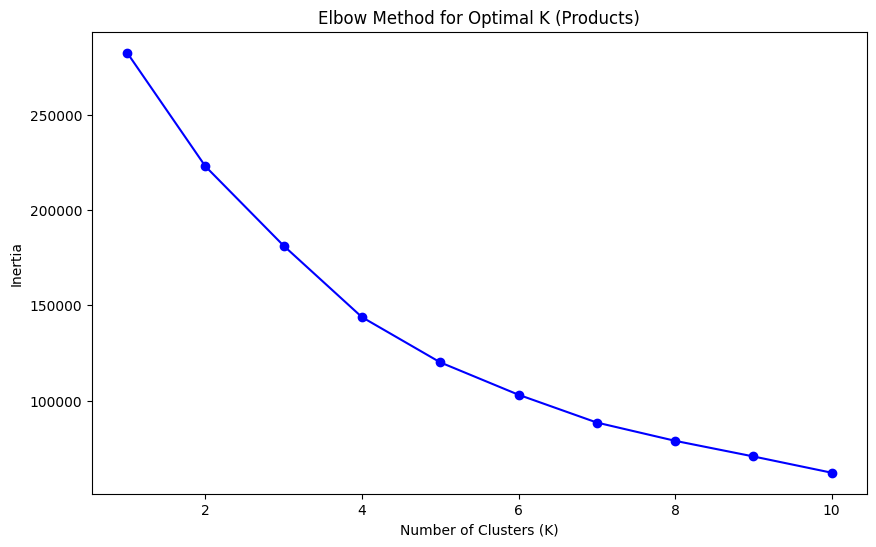


Product Segmentation complete. 'Product_Segment' column added.
     ProductID  Product_Segment
0  AAA-566-EQ4                0
1  AAA-894-HM9                1
2  AAA-930-HY0                1
3  AAB-404-SJ3                0
4  AAB-632-DK3                0

Analysis of Product Segments (Averages):
                  TotalRevenue   TotalProfit  ProfitMargin  SalesQty_sum  \
Product_Segment                                                            
0                  7365.961854  2.266135e+03      0.323259  3.485756e+04   
1                  1165.945138  3.008988e+02      0.238484  5.589611e+03   
2                 10144.200000 -4.532783e+06   -446.834980  1.130000e+05   
3                654923.261486  1.853706e+05      0.316110  1.154828e+07   

                 CustomerBase  PriceVolatility  SalesFrequency  
Product_Segment                                                 
0                    2.366509         0.211583       14.697064  
1                    1.012408         0.002493    

In [5]:

%pip install openpyxl
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


product_df = pd.read_csv(r'c:\Users\Araya\Downloads\product_features_enhanced.csv')

features_for_product_segmentation = [
    'TotalRevenue',
    'TotalProfit',
    'ProfitMargin',
    'SalesQty_sum',         # Represents volume
    'CustomerBase',         # Represents reach/popularity
    'PriceVolatility',
    'SalesFrequency'
]
product_features = product_df[features_for_product_segmentation]

# Step 2: Scale the Data
scaler = StandardScaler()
product_features_scaled = scaler.fit_transform(product_features)

# Step 3: Find Optimal K with Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(product_features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (Products)')
plt.show()

# Step 4: Build and Fit the K-Means Model
# Let's assume the elbow plot suggests K=4 again
optimal_k_product = 4
kmeans_product = KMeans(n_clusters=optimal_k_product, random_state=42, n_init=10)
product_df['Product_Segment'] = kmeans_product.fit_predict(product_features_scaled)

print("\nProduct Segmentation complete. 'Product_Segment' column added.")
print(product_df[['ProductID', 'Product_Segment']].head())

# --- Interpreting the Product Segments ---
segment_analysis_product = product_df.groupby('Product_Segment')[features_for_product_segmentation].mean()
print("\nAnalysis of Product Segments (Averages):")
print(segment_analysis_product)

In [6]:
product_df.to_csv('product_with_segements.csv', index=False)